In [1]:
# Importing libraries needed for data manipulation 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Reading the dataset using pandas
data = pd.read_csv("Downloads/train.csv")

In [3]:
# Creating a DataFrame for us to manipulate the data with
df = pd.DataFrame(data=data)
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [4]:
# Overview of the dataset by checking the head
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# List of all columns of the dataset and their types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# Checking for missing values in the dataset
# Missing values present in Age, Cabin and Embarked columns
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Checking the % of missing values in the column
(df.isna().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: ylabel='Age'>

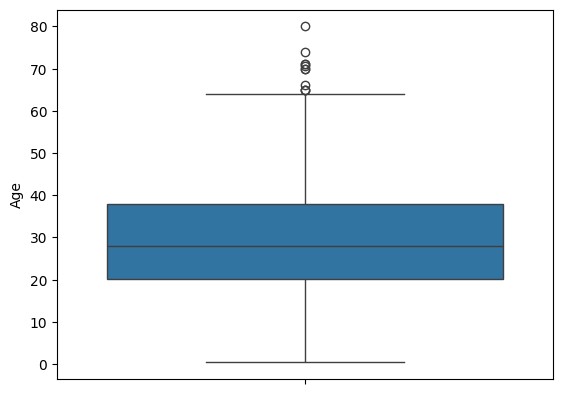

In [8]:
# Checking for outliers in Age category
# Significant amount of outliers are present
sns.boxplot(df['Age'])

<Axes: xlabel='Age', ylabel='Count'>

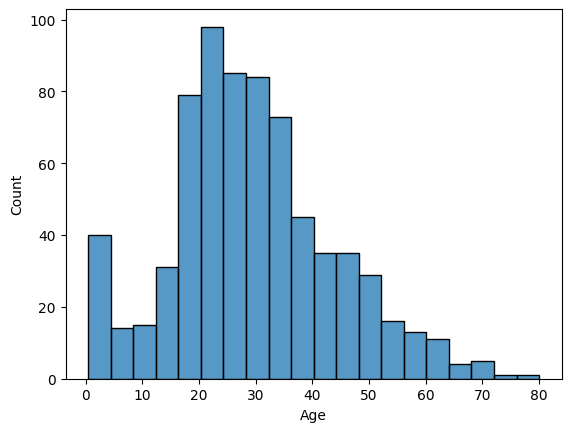

In [9]:
# Checking for skewness of Age category
# The distribution is slightly right-skewed 
sns.histplot(df['Age'])

In [10]:
# Since we do not have a symmetric bell curve and a significant number of outliers are present, we fill missing values with the median of Age instead
# of its mean
median_age = df['Age'].median()

In [11]:
# Filling missing values in Age
df['Age'] = df['Age'].fillna(median_age)

In [12]:
# Obtaining the mode of Embarked, as we have very few missing values, and filling it with the most common value makes the most sense
mode_embarked = df['Embarked'].mode()
print(mode_embarked.values[0])

S


In [13]:
# Filling missing values in Embarked
df['Embarked'] = df['Embarked'].fillna(mode_embarked.values[0])

In [14]:
# Dropping the Cabin category, as too many entries have missing data, and it is not possible to accurately fill the missing values
df = df.drop(['Cabin'],axis=1)

In [15]:
# Checking if missing values have been successfully filled
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
# Handling duplicate values
df.duplicated().sum()

np.int64(0)

In [17]:
# Checking the datatypes of different categories 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [18]:
# Normalization of non-integer-valued categories 
# Binary encoding of Sex category, mapping 1 to male and 0 to female 
df['Sex'] = df['Sex'].map({
    'male':1,
    'female':0
})

# One-hot encoding of the Embarked category being a multi-valued category 
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    dtype=int
)

In [19]:
# Dropping unique identifiers which cannot predict survival status
df = df.drop(['PassengerId','Name','Ticket'],axis=1)

In [20]:
# Verifying the types of normalized categories and the final list of relevant categories for the logistic regression model
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


Survived
0    549
1    342
Name: count, dtype: int64
891
38.38383838383838


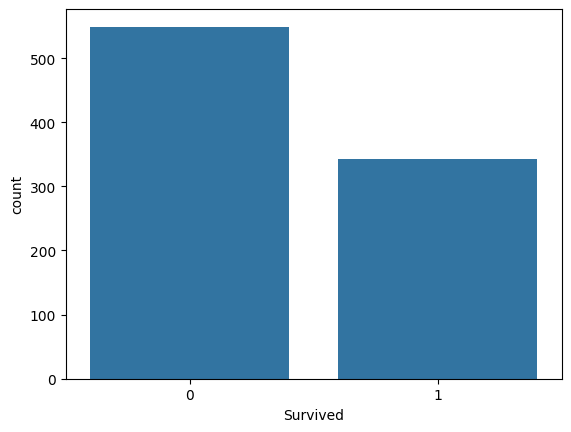

<Figure size 1000x800 with 0 Axes>

In [ ]:
# Countplot comparing the number of fatalities to the number of survivors 
# From this data, we can ascertain that the survival rate was approximately 38.3838 %
count = df['Survived'].value_counts()
print(count)
total_passengers = df['Survived'].count()
print(total_passengers)
survival_rate = count[1]/total_passengers
print(survival_rate*100)
plt.figure(figsize=(10,8))
sns.countplot(x='Survived',data=df)
plt.show()

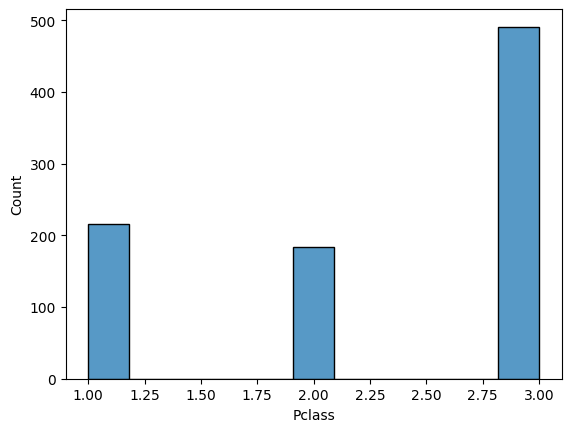

<Figure size 1000x800 with 0 Axes>

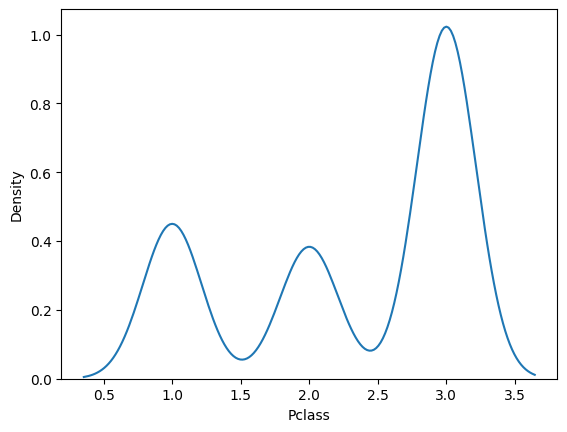

<Figure size 1000x800 with 0 Axes>

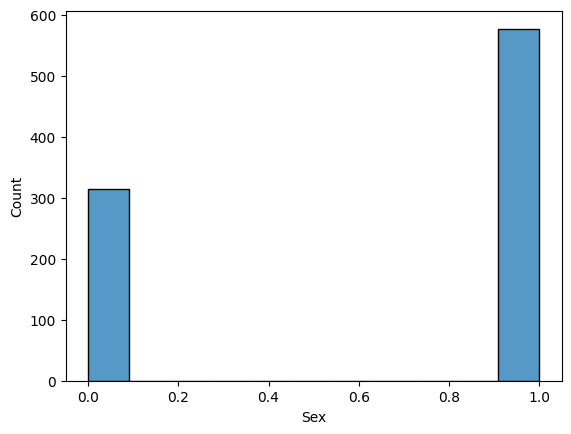

<Figure size 1000x800 with 0 Axes>

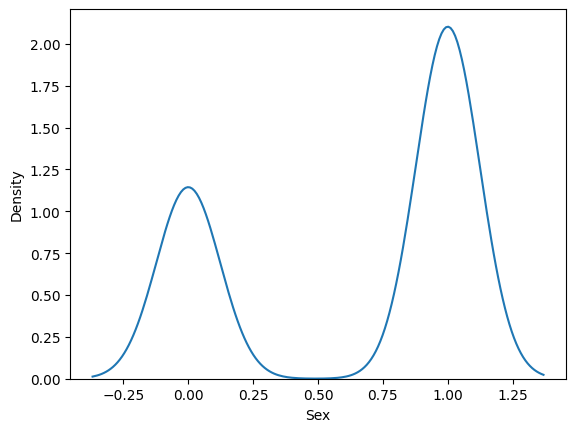

<Figure size 1000x800 with 0 Axes>

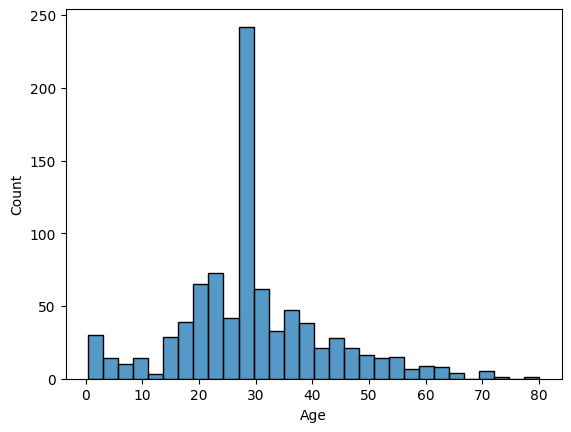

<Figure size 1000x800 with 0 Axes>

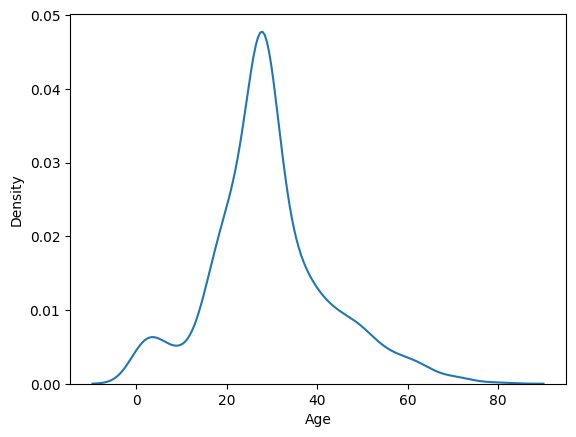

<Figure size 1000x800 with 0 Axes>

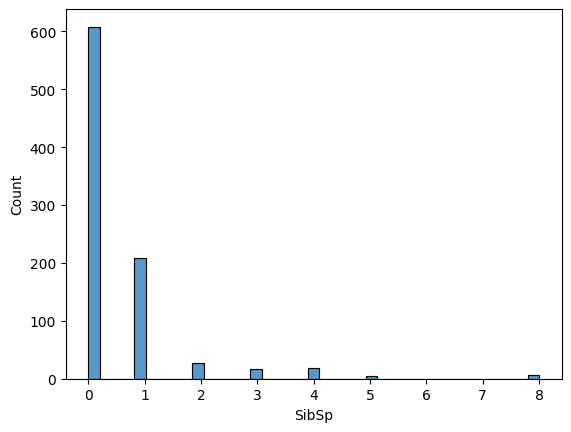

<Figure size 1000x800 with 0 Axes>

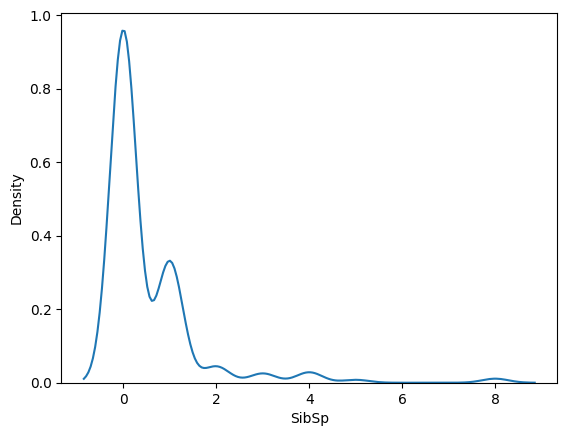

<Figure size 1000x800 with 0 Axes>

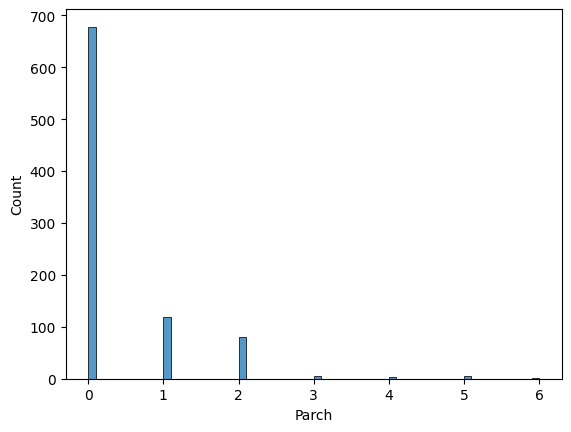

<Figure size 1000x800 with 0 Axes>

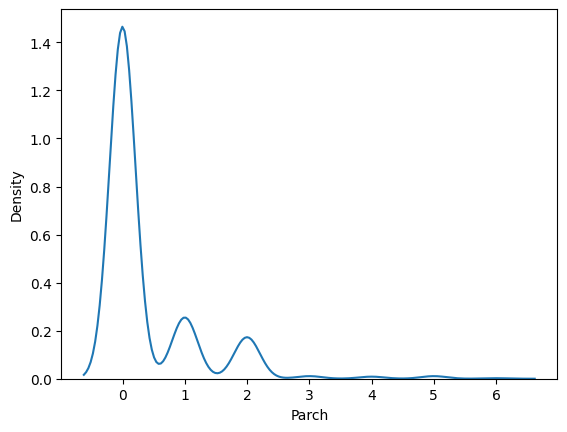

<Figure size 1000x800 with 0 Axes>

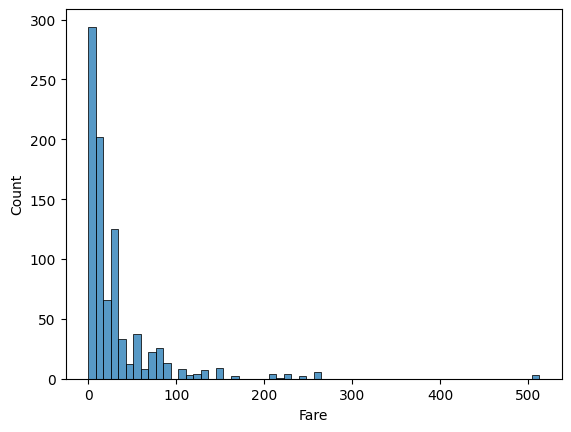

<Figure size 1000x800 with 0 Axes>

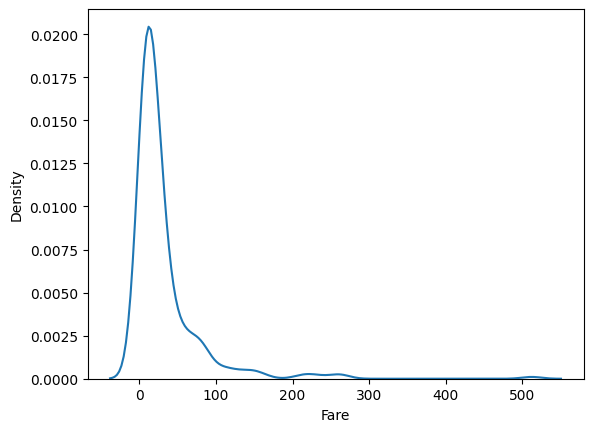

<Figure size 1000x800 with 0 Axes>

In [ ]:
# Analyzing feature distribution using histplots and KDE plots

# Pclass and Sex categories are left-skewed, indicating that the average passenger was a Male travelling in 3rd class, while some affluent 
# passengers are travelling in 1st class

# The age category has a sharp peak in the middle, indicating that most passengers are aged slightly under 30
# The age category is also slightly right-skewed, indicating that the number of passengers under 30 outnumbers the number of passengers above 30

# The SibSp, Parch, and Fare categories are strictly right-skewed, indicating that most passengers are solo travellers, or very small groups who paid 
# base fare (i.e. travelling in 3rd class), while some affluent passengers may be travelling in larger groups in 1st class

columns = ['Pclass','Sex','Age','SibSp','Parch','Fare']
plt.figure(figsize=(10,8))
for column in columns:
    sns.histplot(x=column,data=df)
    plt.show()
    sns.kdeplot(x=column,data=df)
    plt.show()

Series([], Name: Pclass, dtype: int64)


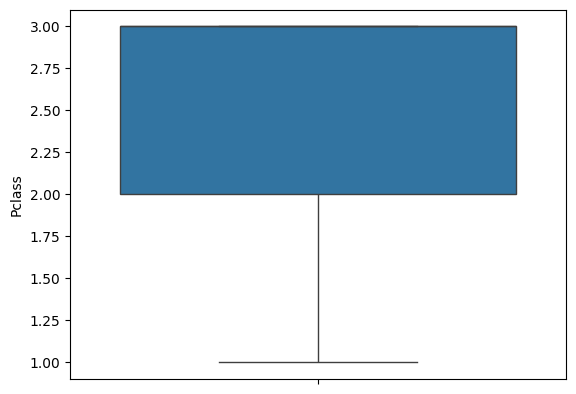

<Figure size 1000x800 with 0 Axes>

Series([], Name: Sex, dtype: int64)


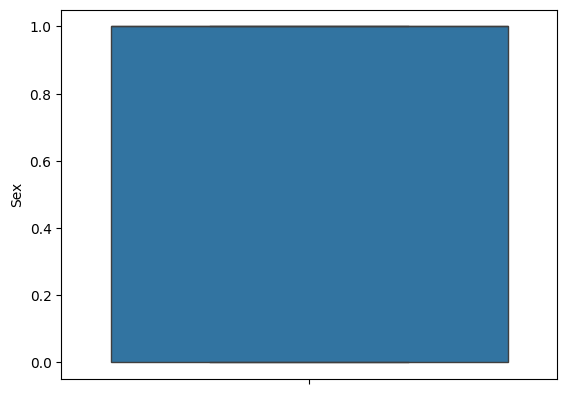

<Figure size 1000x800 with 0 Axes>

7       2.00
11     58.00
15     55.00
16      2.00
33     66.00
       ...  
827     1.00
829    62.00
831     0.83
851    74.00
879    56.00
Name: Age, Length: 66, dtype: float64


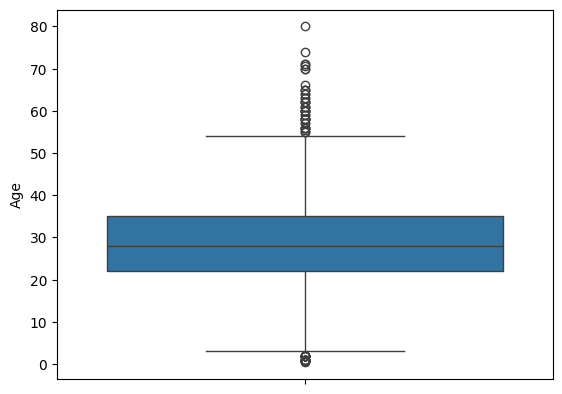

<Figure size 1000x800 with 0 Axes>

7      3
16     4
24     3
27     3
50     4
59     5
63     3
68     4
71     5
85     3
88     3
119    4
159    8
164    4
171    4
176    3
180    8
182    4
201    8
229    3
233    4
261    4
266    4
278    4
324    8
341    3
374    3
386    5
409    3
480    5
485    3
541    4
542    4
634    3
642    3
683    5
686    4
726    3
787    4
792    8
813    4
819    3
824    4
846    8
850    4
863    8
Name: SibSp, dtype: int64


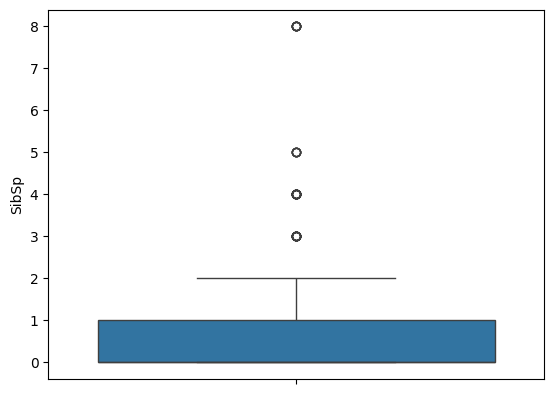

<Figure size 1000x800 with 0 Axes>

7      1
8      2
10     1
13     5
16     1
      ..
871    1
879    1
880    1
885    5
888    2
Name: Parch, Length: 213, dtype: int64


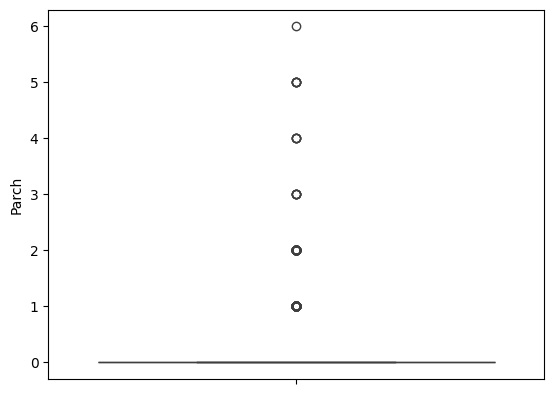

<Figure size 1000x800 with 0 Axes>

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64


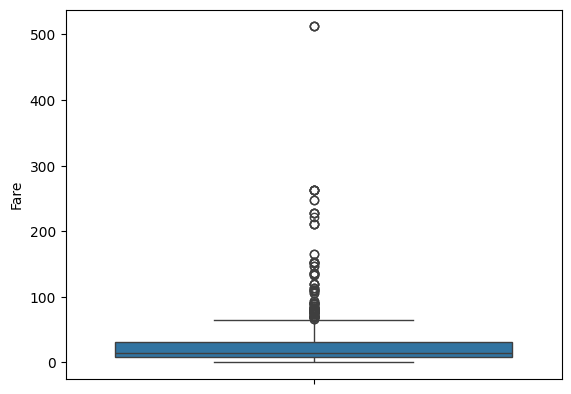

<Figure size 1000x800 with 0 Axes>

In [ ]:
# Checking and analysing the presence of outliers

# The Age category has a good number of outliers, as it generally does not indicate any trend and is relatively more random in nature

# The SibSp, and Parch categories have the most significant number of outliers, as most passengers are solo travellers while few are travelling in 
# groups with families

# The Fare category also has a good number of outliers, as most passengers are travelling in 3rd class paying a lower fare, while a few affluent
# passengers are travelling in 1st class paying a higher fare

columns = ['Pclass','Sex','Age','SibSp','Parch','Fare']
plt.figure(figsize=(10,8))
for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    fare_outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]
    print(fare_outliers[column])
    sns.boxplot(y=column,data=df)
    plt.show()

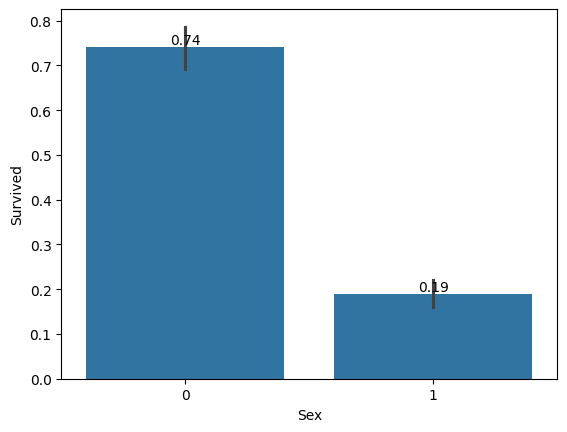

<Figure size 1000x800 with 0 Axes>

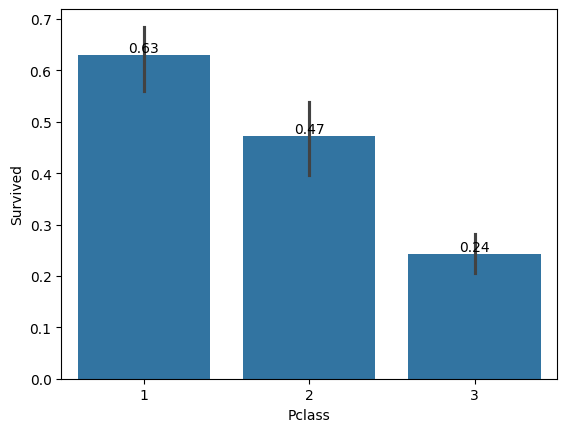

<Figure size 1000x800 with 0 Axes>

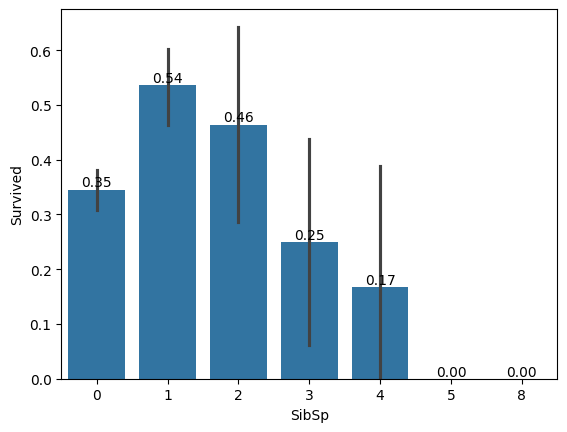

<Figure size 1000x800 with 0 Axes>

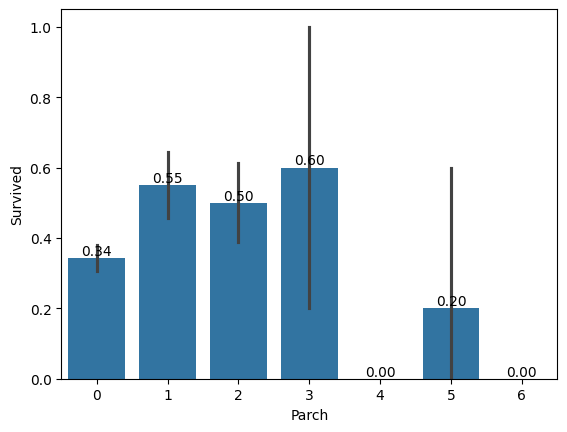

<Figure size 1000x800 with 0 Axes>

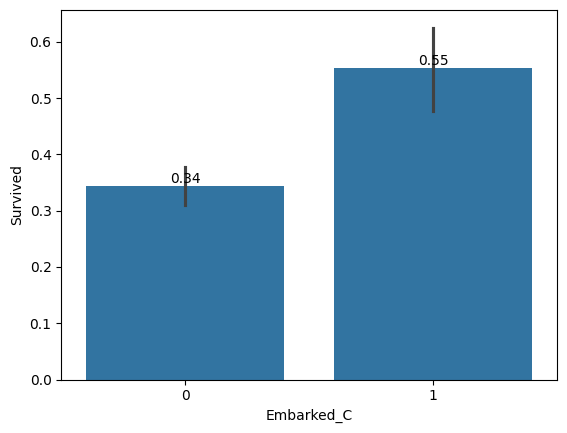

<Figure size 1000x800 with 0 Axes>

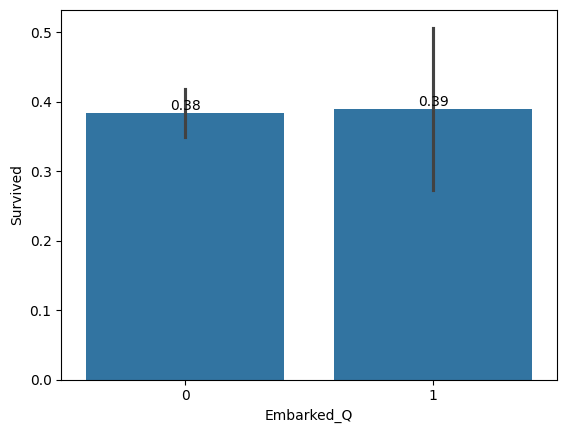

<Figure size 1000x800 with 0 Axes>

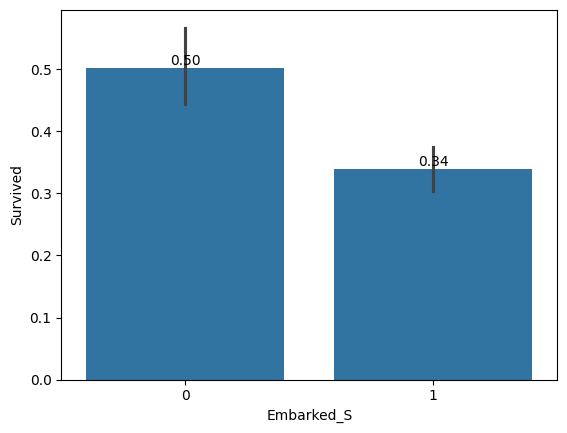

<Figure size 1000x800 with 0 Axes>

In [24]:
# Plotting barplots of binary-valued or small multi-value categories and analysing the average survival rate based on them
# Women had a survival rate of 74%, while men had a much lower survival rate of 19%, which is strongly supported by the women and children first 
# policy of the lifeboats

# 1st class passengers had a survival rate of 63%
# 2nd class passengers had a survival rate of 47%
# 3rd class passengers had a survival rate of 24%
# This is strongly supported by the fact that passengers in 1st class and 2nd class were given more priority while evacuating, while lower class
# passengers were given the least priority

# Passengers with small families, having mothers, sisters, and children (younger siblings) with somebody to accompany them often had relatively 
# greater survival rates, even if a large number of families were separated

# Passengers who embarked on port C had a relatively higher survival rate as compared to passengers who embarked on ports Q and S,
# as this consisted of predominantly 1st class passengers

columns = ['Sex','Pclass','SibSp','Parch','Embarked_C','Embarked_Q','Embarked_S']
for column in columns:
    ax = sns.barplot(x=column,y='Survived',data=df)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')
    plt.figure(figsize=(10,8))
    plt.show()

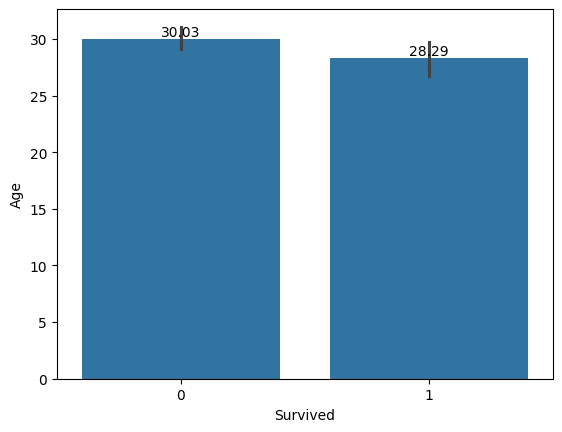

<Figure size 1000x800 with 0 Axes>

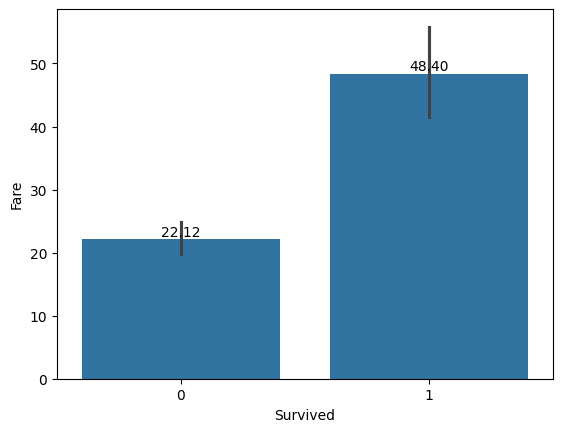

<Figure size 1000x800 with 0 Axes>

In [25]:
# Plotting barplots of large multi-valued categories and analysing the average survival rate based on them

# Average ages of survivors and fatalities are similar, as age is more widely distributed and has high variance

# Survivors paid higher fare on average corresponding to higher class cabins, as opposed to lower average fare of the non-survivors corresponding to
# lower class cabins
columns = ['Age','Fare']
for column in columns:
    ax = sns.barplot(y=column,x='Survived',data=df)
    for container in ax.containers:
        ax.bar_label(container,fmt="%.2f")
    plt.figure(figsize=(10,8))
    plt.show()

Survived      1.000000
Fare          0.257307
Embarked_C    0.168240
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


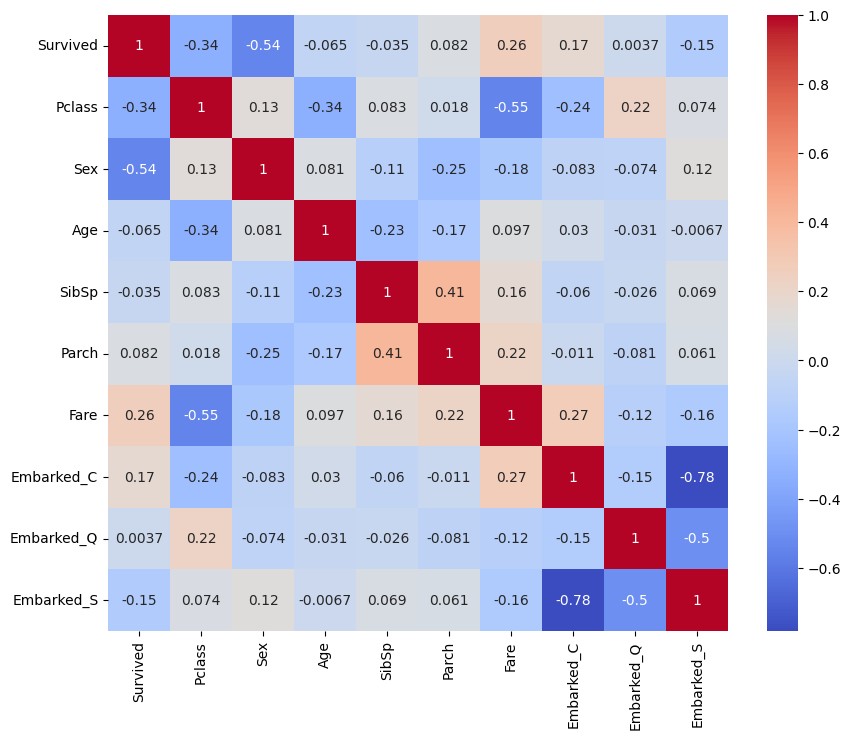

In [26]:
# Checking for multicollinearity between categories with the help of a correlation heatmap
corr = df.corr(numeric_only=True)
print(corr['Survived'].sort_values(ascending=False))
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [27]:
# Checking for multicollinearity between categories with the help of the Variance Inflation Factor (VIF)
# Embarked_S has the highest VIF due to one-hot encoding and separation of the Embarked category into multiple categories
X = df.drop('Survived', axis=1)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]
print(vif)

      Feature        VIF
0      Pclass   1.772613
1         Sex   1.124209
2         Age   1.216737
3       SibSp   1.284166
4       Parch   1.331368
5        Fare   1.649294
6  Embarked_C   6.314528
7  Embarked_Q   4.063228
8  Embarked_S  22.742050


In [28]:
# Dropping Embarked_S to reduce multicollinearity between factors
df = df.drop('Embarked_S',axis=1)

In [29]:
# High multicollinearity persists among categories, as Pclass and Sex are linked in terms of survivability
X = df.drop('Survived', axis=1)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]
print(vif)

      Feature       VIF
0      Pclass  5.056465
1         Sex  3.090956
2         Age  4.235139
3       SibSp  1.567902
4       Parch  1.622913
5        Fare  1.836087
6  Embarked_C  1.342828
7  Embarked_Q  1.197560


In [30]:
# Downloading the cleaned dataset
df.to_csv('titanic_train_cleaned.csv', index=False)